In [8]:
from scipy.integrate import quad
from scipy import integrate
from astropy import units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, wcsaxes #wcsaxes manages coordinates of the plot.
plt.style.use(astropy_mpl_style)
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS #This package expresses coordinates of the image file.
import warnings
from GtApp import GtApp
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, wcsaxes #wcsaxes manages coordinates of the plot.
plt.style.use(astropy_mpl_style)
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS #This package expresses coordinates of the image file.
import numpy as np
from astropy.table import Table, hstack
import xml.etree.ElementTree as ET
from astropy.coordinates import SkyCoord
import astropy.units as u
from LATSourceModel import SourceList
from scipy.interpolate import interp1d
import warnings
from multiprocessing import Pool
import time

In [131]:
def angle(l, b):
    eccentricity=1
    return np.arccos(np.cos(np.radians(l/eccentricity)) * np.cos(np.radians(b)))
    #Returns angular distance theta in terms of Galactic coordinate system

def wimp_annihilation_map(l, b):
    def NFW(r): #Takes distance from Galactic center
        rho_s = 0.2710150839697834 #GeV/cm^3, Normalization factor, density profile at r=r_0(8.5kpc, Distance from Galactic center and the sun.)
        #Assumes local Dark matter density is 0.4GeV/cm^3
        r_s = 20 #kpc, scale radius for Milky way halo
        gamma = 1.2 #Slope of the profile
        return rho_s*( (r/r_s)**-gamma )/( (1+r/r_s)**(3-gamma) )
        #return value is in dimension of GeV/cm^3
        #Input value is distance from the Galactic center, kpc
    def R(s):#s is line of sight distance >=0, theta is angular separation from the GC
        r_0=8.5 #kpc, distance from the earth and the GC
        theta = angle(l, b)  # Already returns angle in radians
        return np.sqrt(r_0 ** 2 + s ** 2 - 2 * r_0 * s * np.cos(theta))  # Distance from Galactic center    
    
    def rho_squared(s):
        return NFW( R(s) )**2
        
    def rho_squared_log(u):
        s = np.exp(u) - 1  # Change of variable s = exp(u) - 1
        return NFW(R(s)) ** 2 * np.exp(u)  # Include Jacobian factor from ds = exp(u) du

    
    result, error = integrate.quad(rho_squared_log, 0, np.log(500), epsabs=1e-8, epsrel=1e-8)
        
    warnings.filterwarnings("ignore", category=integrate.IntegrationWarning)
    return result, error
    #return integrate.quad(rho_squared, 0, 400)

In [145]:
angle(0.01, 0.01)

0.0002468268288832088

In [155]:
def angle(l, b):
    eccentricity=1
    return np.arccos(np.cos(np.radians(l/eccentricity)) * np.cos(np.radians(b)))
    #Returns angular distance theta in terms of Galactic coordinate system

def wimp_annihilation_map(l, b):
    def NFW(r): #Takes distance from Galactic center
        rho_s = 0.2710150839697834 #GeV/cm^3, Normalization factor, density profile at r=r_0(8.5kpc, Distance from Galactic center and the sun.)
        #Assumes local Dark matter density is 0.4GeV/cm^3
        r_s = 20 #kpc, scale radius for Milky way halo
        gamma = 1.2 #Slope of the profile
        return rho_s*( (r/r_s)**-gamma )/( (1+r/r_s)**(3-gamma) )
        #return value is in dimension of GeV/cm^3
        #Input value is distance from the Galactic center, kpc
    def R(s):#s is line of sight distance >=0, theta is angular separation from the GC
        r_0=8.5 #kpc, distance from the earth and the GC
        theta = angle(l, b)  # Already returns angle in radians
        if theta < angle(0.005, 0.005):
            theta = angle(0.005, 0.005)
        return np.sqrt(r_0 ** 2 + s ** 2 - 2 * r_0 * s * np.cos(theta))  # Distance from Galactic center    
    
    def rho_squared(s):
        return NFW( R(s) )**2
        
    def rho_squared_log(u):
        s = np.exp(u) - 1  # Change of variable s = exp(u) - 1
        return NFW(R(s)) ** 2 * np.exp(u)  # Include Jacobian factor from ds = exp(u) du

    
    result, error = integrate.quad(rho_squared, 0, np.inf, epsabs=1e-20, epsrel=1e-20)
        
    warnings.filterwarnings("ignore", category=integrate.IntegrationWarning)
    return result, error
    #return integrate.quad(rho_squared, 0, 400)

In [156]:
wimp_annihilation_map(0, 0)

(3615026.9889564873, 0.004058456712113174)

In [154]:
wimp_annihilation_map(0, 0)

(13049.791660676348, 5880.165643115817)

In [70]:
rho_squared_log(100)

9.116913377006222e+37

In [200]:
raw_map=fits.open(f'./GC_analysis/GC_all_time_60x60_cmap{front}_12yr_CAR.fits')
w=WCS(raw_map[0].header)
# Define the dimensions of the numpy array
width, height = np.shape(raw_map[0].data)

# Create the counts map
counts_map=np.zeros([width, height])

for i in range(0, height, 1):
    for j in range(0, width, 1):
        l, b = w.wcs_pix2world(j, i, 0) #x-axis array - b, y-axis array - l
        if True:#angle(l, b) < np.radians(120):
            if False:#angle(l, b) < angle(0.05, 0.05):
                counts_map[i, j] = wimp_annihilation_map(0.05, 0.05)[0]
            else:
                counts_map[i, j] = wimp_annihilation_map(l, b)[0]
duplicate=raw_map.copy()
norm = np.sum(counts_map[0])*(np.pi/180)**2 * (0.01)**2
duplicate[0].data = counts_map/norm
del duplicate[1]

#duplicate.writeto('./FermiLAT/wimp_map_CAR_test_3.fits', overwrite=True)


Set MJD-END to 59323.999942 from DATE-END'. [astropy.wcs.wcs]


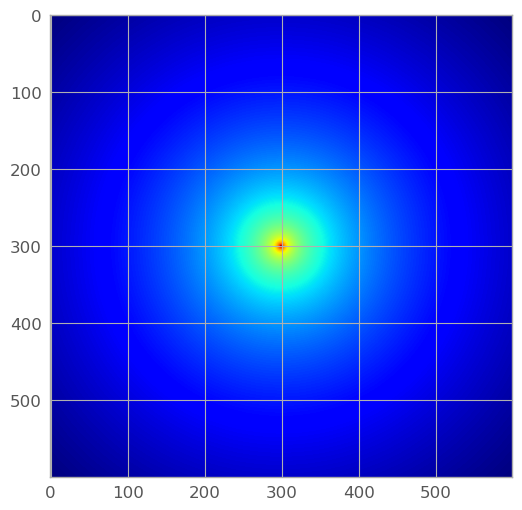

In [203]:
plt.imshow(np.log(counts_map/norm), cmap='jet')

In [ ]:
rho_squared_log()

In [32]:
def angle(l, b):
    eccentricity=1
    return np.arccos(np.cos(np.radians(l/eccentricity)) * np.cos(np.radians(b)))
    #Returns angular distance theta in terms of Galactic coordinate system

def wimp_annihilation_map(l, b):
    def NFW(r): #Takes distance from Galactic center
        rho_s = 0.2710150839697834 #GeV/cm^3, Normalization factor, density profile at r=r_0(8.5kpc, Distance from Galactic center and the sun.)
        #Assumes local Dark matter density is 0.4GeV/cm^3
        r_s = 20 #kpc, scale radius for Milky way halo
        gamma = 1.2 #Slope of the profile
        return rho_s*( (r/r_s)**-gamma )/( (1+r/r_s)**(3-gamma) )
        #return value is in dimension of GeV/cm^3
        #Input value is distance from the Galactic center, kpc
    def R(s):#s is line of sight distance >=0, theta is angular separation from the GC
        r_0=8.5 #kpc, distance from the earth and the GC
        theta = angle(l, b)  # Already returns angle in radians
        return np.sqrt(r_0 ** 2 + s ** 2 - 2 * r_0 * s * np.cos(theta))  # Distance from Galactic center    
    
    def rho_squared(s):
        return NFW( R(s) )**2
        
    warnings.filterwarnings("ignore", category=integrate.IntegrationWarning)
    return integrate.quad(rho_squared, 0, 400)

In [104]:
#For whole ROI ccube, use this code
front='_front'
counts_map = GtApp('gtbin', 'evtbin')
counts_map['algorithm']='CMAP'
counts_map['evfile']=f'./GC_analysis/Allsky_all_time_gti{front}_12yr.fits'
counts_map['outfile']=f'./GC_analysis/Allsky_all_time_60x60_cmap{front}_12yr_AIT.fits'
counts_map['nxpix']=2400
counts_map['nypix']=1800
counts_map['binsz']=0.1
counts_map['coordsys']='GAL'
counts_map['xref']=0
counts_map['yref']=0
counts_map['axisrot']=0
counts_map['proj']='AIT'
#counts_map['proj']='CAR'
#counts_map['ebinalg']='FILE'
#counts_map['ebinalg']='LOG'
#counts_map['ebinfile']='./GC_analysis/bin_definitions.fits'
#counts_map['emin']=300
#counts_map['emax']=500000
#counts_map['enumbins']=20
counts_map.run()

time -p gtbin evfile=./GC_analysis/Allsky_all_time_gti_front_12yr.fits scfile=NONE outfile=./GC_analysis/Allsky_all_time_60x60_cmap_front_12yr_AIT.fits algorithm="CMAP" ebinalg="FILE" emin=30.0 emax=200000.0 enumbins=0 denergy=0.0 ebinfile=./GC_analysis/bin_definitions.fits tbinalg="LIN" tstart=0.0 tstop=0.0 dtime=0.0 tbinfile=NONE snratio=0.0 lcemin=0.0 lcemax=0.0 nxpix=2400 nypix=1800 binsz=0.1 coordsys="GAL" xref=0.0 yref=0.0 axisrot=0.0 rafield="RA" decfield="DEC" proj="AIT" hpx_ordering_scheme="RING" hpx_order=3 hpx_ebin=yes hpx_region="" evtable="EVENTS" sctable="SC_DATA" efield="ENERGY" tfield="TIME" chatter=2 clobber=yes debug=no gui=no mode="ql"
This is gtbin version HEAD
gtbin: WARNING: No spacecraft file: EXPOSURE keyword will be set equal to ontime.
real 82.22
user 70.46
sys 2.75


In [139]:
#For whole ROI ccube, use this code
front='_front'
counts_map = GtApp('gtbin', 'evtbin')
counts_map['algorithm']='CMAP'
counts_map['evfile']=f'./GC_analysis/Allsky_all_time_gti{front}_12yr.fits'
counts_map['outfile']=f'./GC_analysis/Allsky_all_time_60x60_cmap{front}_12yr_CAR.fits'
counts_map['nxpix']=2400
counts_map['nypix']=1800
counts_map['binsz']=0.1
counts_map['coordsys']='GAL'
counts_map['xref']=0
counts_map['yref']=0
counts_map['axisrot']=0
counts_map['proj']='CAR'
#counts_map['proj']='CAR'
#counts_map['ebinalg']='FILE'
#counts_map['ebinalg']='LOG'
#counts_map['ebinfile']='./GC_analysis/bin_definitions.fits'
#counts_map['emin']=300
#counts_map['emax']=500000
#counts_map['enumbins']=20
counts_map.run()

time -p gtbin evfile=./GC_analysis/Allsky_all_time_gti_front_12yr.fits scfile=NONE outfile=./GC_analysis/Allsky_all_time_60x60_cmap_front_12yr_CAR.fits algorithm="CMAP" ebinalg="FILE" emin=30.0 emax=200000.0 enumbins=0 denergy=0.0 ebinfile=./GC_analysis/bin_definitions.fits tbinalg="LIN" tstart=0.0 tstop=0.0 dtime=0.0 tbinfile=NONE snratio=0.0 lcemin=0.0 lcemax=0.0 nxpix=2400 nypix=1800 binsz=0.1 coordsys="GAL" xref=0.0 yref=0.0 axisrot=0.0 rafield="RA" decfield="DEC" proj="CAR" hpx_ordering_scheme="RING" hpx_order=3 hpx_ebin=yes hpx_region="" evtable="EVENTS" sctable="SC_DATA" efield="ENERGY" tfield="TIME" chatter=2 clobber=yes debug=no gui=no mode="ql"
This is gtbin version HEAD
gtbin: WARNING: No spacecraft file: EXPOSURE keyword will be set equal to ontime.
real 231.96
user 70.38
sys 3.17


In [192]:
#For whole ROI ccube, use this code
front='_front'
counts_map = GtApp('gtbin', 'evtbin')
counts_map['algorithm']='CMAP'
counts_map['evfile']=f'./GC_analysis/Allsky_all_time_gti{front}_12yr.fits'
counts_map['outfile']=f'./GC_analysis/GC_all_time_60x60_cmap{front}_12yr_CAR_highresol.fits'
counts_map['nxpix']=6000
counts_map['nypix']=6000
counts_map['binsz']=0.01
counts_map['coordsys']='GAL'
counts_map['xref']=0
counts_map['yref']=0
counts_map['axisrot']=0
counts_map['proj']='CAR'
#counts_map['proj']='CAR'
#counts_map['ebinalg']='FILE'
#counts_map['ebinalg']='LOG'
#counts_map['ebinfile']='./GC_analysis/bin_definitions.fits'
#counts_map['emin']=300
#counts_map['emax']=500000
#counts_map['enumbins']=20
counts_map.run()

time -p gtbin evfile=./GC_analysis/Allsky_all_time_gti_front_12yr.fits scfile=NONE outfile=./GC_analysis/GC_all_time_60x60_cmap_front_12yr_CAR_highresol.fits algorithm="CMAP" ebinalg="FILE" emin=30.0 emax=200000.0 enumbins=0 denergy=0.0 ebinfile=./GC_analysis/bin_definitions.fits tbinalg="LIN" tstart=0.0 tstop=0.0 dtime=0.0 tbinfile=NONE snratio=0.0 lcemin=0.0 lcemax=0.0 nxpix=6000 nypix=6000 binsz=0.01 coordsys="GAL" xref=0.0 yref=0.0 axisrot=0.0 rafield="RA" decfield="DEC" proj="CAR" hpx_ordering_scheme="RING" hpx_order=3 hpx_ebin=yes hpx_region="" evtable="EVENTS" sctable="SC_DATA" efield="ENERGY" tfield="TIME" chatter=2 clobber=yes debug=no gui=no mode="ql"
This is gtbin version HEAD
gtbin: WARNING: No spacecraft file: EXPOSURE keyword will be set equal to ontime.
real 67.66
user 61.81
sys 4.06


In [272]:
#For whole ROI ccube, use this code
front='_front'
counts_map = GtApp('gtbin', 'evtbin')
counts_map['algorithm']='CMAP'
counts_map['evfile']=f'./GC_analysis/Allsky_all_time_gti{front}_12yr.fits'
counts_map['outfile']=f'./GC_analysis/GC_all_time_60x60_cmap{front}_12yr_AIT_highresol.fits'
counts_map['nxpix']=6000
counts_map['nypix']=6000
counts_map['binsz']=0.01
counts_map['coordsys']='GAL'
counts_map['xref']=0
counts_map['yref']=0
counts_map['axisrot']=0
counts_map['proj']='AIT'
#counts_map['proj']='CAR'
#counts_map['ebinalg']='FILE'
#counts_map['ebinalg']='LOG'
#counts_map['ebinfile']='./GC_analysis/bin_definitions.fits'
#counts_map['emin']=300
#counts_map['emax']=500000
#counts_map['enumbins']=20
counts_map.run()

time -p gtbin evfile=./GC_analysis/Allsky_all_time_gti_front_12yr.fits scfile=NONE outfile=./GC_analysis/GC_all_time_60x60_cmap_front_12yr_AIT_highresol.fits algorithm="CMAP" ebinalg="FILE" emin=30.0 emax=200000.0 enumbins=0 denergy=0.0 ebinfile=./GC_analysis/bin_definitions.fits tbinalg="LIN" tstart=0.0 tstop=0.0 dtime=0.0 tbinfile=NONE snratio=0.0 lcemin=0.0 lcemax=0.0 nxpix=6000 nypix=6000 binsz=0.01 coordsys="GAL" xref=0.0 yref=0.0 axisrot=0.0 rafield="RA" decfield="DEC" proj="AIT" hpx_ordering_scheme="RING" hpx_order=3 hpx_ebin=yes hpx_region="" evtable="EVENTS" sctable="SC_DATA" efield="ENERGY" tfield="TIME" chatter=2 clobber=yes debug=no gui=no mode="ql"
This is gtbin version HEAD
gtbin: WARNING: No spacecraft file: EXPOSURE keyword will be set equal to ontime.
real 1026.18
user 87.33
sys 10.62


In [183]:
raw_map=fits.open('./GC_analysis/Allsky_all_time_60x60_cmap_front_12yr_AIT.fits')
w=WCS(raw_map[0].header)
# Define the dimensions of the numpy array
width, height = np.shape(raw_map[0].data)

# Create the counts map
counts_map=np.zeros([width, height])

for i in range(0, height, 1):
    for j in range(0, width, 1):
        l, b = w.wcs_pix2world(j, i, 0) #x-axis array - b, y-axis array - l
        if angle(l, b) < np.radians(120):
            if angle(l, b) < angle(0.05, 0.05):
                counts_map[i, j] = wimp_annihilation_map(0.05, 0.05)[0]
            else:
                counts_map[i, j] = wimp_annihilation_map(l, b)[0]
duplicate=raw_map.copy()
norm = np.sum(counts_map[0])*(np.pi/180)**2 * (0.1)**2
duplicate[0].data = counts_map#/norm
del duplicate[1]

duplicate.writeto('./FermiLAT/wimp_map_AIT.fits', overwrite=True)


In [140]:
raw_map=fits.open('./GC_analysis/Allsky_all_time_60x60_cmap_front_12yr_CAR.fits')
w=WCS(raw_map[0].header)
# Define the dimensions of the numpy array
width, height = np.shape(raw_map[0].data)

# Create the counts map
counts_map=np.zeros([width, height])

i, j, m = 0, 0, 0
#for m in range(0, len(raw_map[0].data), 1):
for i in range(0, height, 1):
    for j in range(0, width, 1):
        #l, b = w.dropaxis(2).wcs_pix2world(j, i, 0) #x-axis array - b, y-axis array - l
        l, b = w.wcs_pix2world(j, i, 0) #x-axis array - b, y-axis array - l
        if angle(l, b) < np.radians(120):
            if angle(l, b) < angle(0.05, 0.05):
                counts_map[i, j] = wimp_annihilation_map(0.05, 0.05)[0]
            else:
                counts_map[i, j] = wimp_annihilation_map(l, b)[0];
        #if np.arccos( np.cos(l * np.pi/180) * np.cos(b * np.pi/180) ) < 30*np.pi/180: #cut for the angular distance
            #if np.arccos( np.cos(l * np.pi/180) * np.cos(b * np.pi/180) ) <= 0.006170660957344974: #0.002468267672409618: # Those two if loops are to avoid ugly behavior of NFW near center of the Galaxy
                #counts_map[m, i, j] = wimp_annihilation_map(0.25, 0.25)[0];
            #else:
                #counts_map[m, i, j] = wimp_annihilation_map(l, b)[0];
        #else:
            #map[m, i, j] = 0


Set MJD-END to 59323.999942 from DATE-END'. [astropy.wcs.wcs]


In [178]:
raw_map=fits.open(f'./GC_analysis/Allsky_all_time_60x60_cmap{front}_12yr_CAR.fits')
w=WCS(raw_map[0].header)
# Define the dimensions of the numpy array
width, height = np.shape(raw_map[0].data)

# Create the counts map
counts_map=np.zeros([width, height])
print(np.shape(counts_map))
for i in range(0, width, 1):
    for j in range(0, height, 1):
        l, b = w.wcs_pix2world(j, i, 0) #x-axis array - b, y-axis array - l
        counts_map[i, j] = wimp_annihilation_map(l, b)[0]
        #if True:#angle(l, b) < np.radians(120):
            #if False:#if angle(l, b) < angle(0.05, 0.05):
                #counts_map[i, j] = wimp_annihilation_map(0.05, 0.05)[0]
            #else:
                #counts_map[i, j] = wimp_annihilation_map(l, b)[0]
duplicate=raw_map.copy()
norm = np.sum(counts_map[0])*(np.pi/180)**2 * (0.1)**2
duplicate[0].data = counts_map/norm
del duplicate[1]

duplicate.writeto('./FermiLAT/wimp_map_CAR_wide_test.fits', overwrite=True)


Set MJD-END to 59323.999942 from DATE-END'. [astropy.wcs.wcs]


(1800, 2400)


In [176]:
np.shape(counts_map)

(1800, 2400)

In [177]:
height

2400

In [169]:
norm

0.00016530701574852416

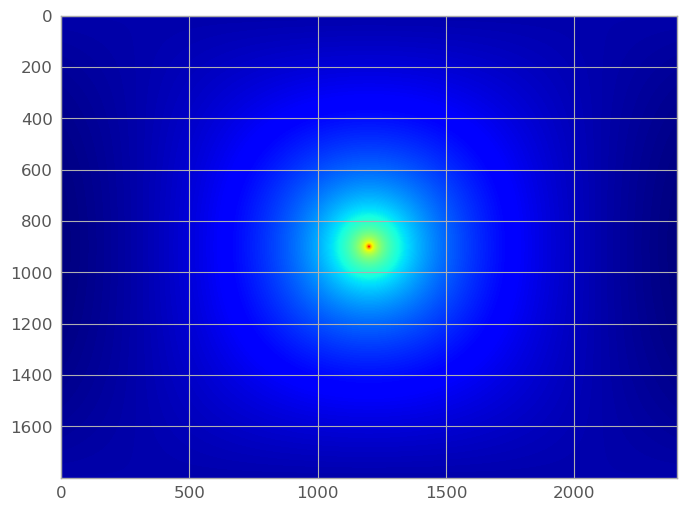

In [179]:
plt.imshow(np.log(counts_map), cmap='jet')

In [45]:
front='_front'
raw_map=fits.open(f'./GC_analysis/GC_all_time_60x60_cmap{front}_12yr_AIT_highresol.fits')
w=WCS(raw_map[0].header)
# Define the dimensions of the numpy array
width, height = np.shape(raw_map[0].data)

# Create the counts map
counts_map=np.zeros([width, height])

for i in range(0, height, 1):
    for j in range(0, width, 1):
        l, b = w.wcs_pix2world(j, i, 0) #x-axis array - b, y-axis array - l
        if abs(angle(l, b)) < np.radians(120):
            if abs(angle(l, b)) < angle(0.05, 0.05):
                counts_map[i, j] = wimp_annihilation_map(0.05, 0.05)[0]
            else:
                counts_map[i, j] = wimp_annihilation_map(l, b)[0]
duplicate=raw_map.copy()
norm = np.sum(counts_map[0])*(np.pi/180)**2 * (0.01)**2
duplicate[0].data = counts_map/norm
del duplicate[1]

duplicate.writeto('./FermiLAT/wimp_map_AIT_highresol.fits', overwrite=True)


Set MJD-END to 59323.999942 from DATE-END'. [astropy.wcs.wcs]


In [260]:
raw_map=fits.open(f'./GC_analysis/GC_all_time_60x60_cmap{front}_12yr_CAR.fits')
w=WCS(raw_map[0].header)
# Define the dimensions of the numpy array
width, height = np.shape(raw_map[0].data)

# Create the counts map
counts_map=np.zeros([width, height])

for i in range(0, height, 1):
    for j in range(0, width, 1):
        l, b = w.wcs_pix2world(j, i, 0) #x-axis array - b, y-axis array - l
        if angle(l, b) < np.radians(120):
            if angle(l, b) < angle(0.05, 0.05):
                counts_map[i, j] = wimp_annihilation_map(0.05, 0.05)[0]
            else:
                counts_map[i, j] = wimp_annihilation_map(l, b)[0]
duplicate=raw_map.copy()
norm = np.sum(counts_map[0])*(np.pi/180)**2 * (0.01)**2
duplicate[0].data = counts_map/norm
del duplicate[1]

duplicate.writeto('./FermiLAT/wimp_map_CAR_test_2.fits', overwrite=True)


Set MJD-END to 59323.999942 from DATE-END'. [astropy.wcs.wcs]


8.288513837994771e-05

In [200]:
duplicate=raw_map.copy()
norm = np.sum(counts_map[0])*(np.pi/180)**2 * (0.01)**2
duplicate[0].data = counts_map/norm
del duplicate[1]

duplicate.writeto('./FermiLAT/wimp_map_CAR_highresol.fits', overwrite=True)


In [141]:
duplicate=raw_map.copy()
norm = np.sum(counts_map[0])*(np.pi/180)**2 * (0.1)**2
duplicate[0].data = counts_map#/norm
del duplicate[1]

In [130]:
duplicate.writeto('./FermiLAT/wimp_map.fits', overwrite=True)

In [142]:
duplicate.writeto('./FermiLAT/wimp_map_CAR.fits', overwrite=True)

Set MJD-END to 59323.999942 from DATE-END'. [astropy.wcs.wcs]


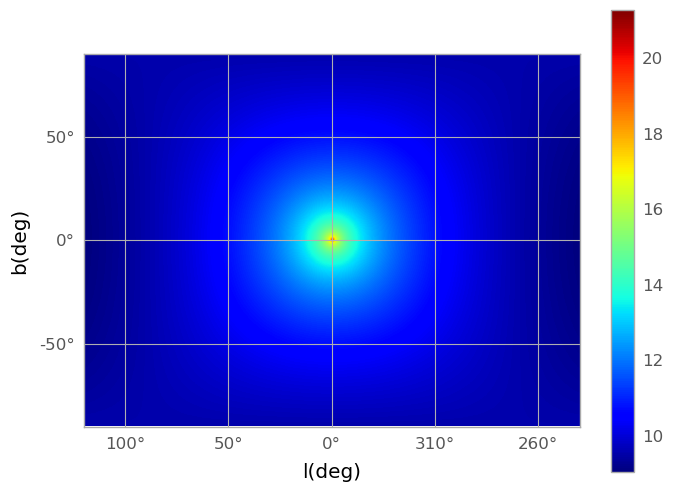

In [206]:
#disk_mask=np.load('./GC_analysis/Model/GC_disk_mask_60x60_definitions.npy')
#exposure=fits.open('./GC_analysis/GC_all_time_60x60_expcube_front_center_12yr.fits')[0].data
#src_1=fits.open('./GC_analysis/Allsky_all_time_60x60_cmap_front_12yr_AIT.fits')
#src_1=fits.open('./GC_analysis/Allsky_all_time_60x60_cmap_front_12yr_AIT.fits')
src_1=fits.open('./FermiLAT/wimp_map_CAR_wide_test.fits')
w=WCS(src_1[0].header)


fig=plt.figure()
ax=fig.add_subplot(111,projection=w)
ax.coords[0].set_format_unit('deg', decimal=True, show_decimal_unit=True)
ax.coords[1].set_format_unit('deg', decimal=True, show_decimal_unit=True) #Changing coordinate tick label into decimal.
n=0
plot=ax.imshow( np.log(src_1[0].data) , origin='lower', cmap='jet', interpolation='none')
#plot=ax.imshow(copied[10])
#plot=ax.imshow(full_mask[10])
#plt.grid(color='white', ls='solid')
plt.xlabel('l(deg)')
plt.ylabel('b(deg)')
plt.colorbar(plot)


In [211]:
np.sum(src_1[0].data - np.flip(src_1[0].data, axis=1))

0.0

In [196]:
np.max((src_1[0].data - np.flip(src_1[0].data, axis=1)))

3.8940925151109695e-08

In [199]:
np.max(src_1[0].data)

17295320.78195055

Set MJD-END to 59323.999942 from DATE-END'. [astropy.wcs.wcs]
/tmp/ipykernel_2415206/2365928729.py:14: RuntimeWarning: divide by zero encountered in log
  plot=ax.imshow( np.log(src_2[0].data - src_1[0].data), origin='lower', cmap='jet', interpolation='none')


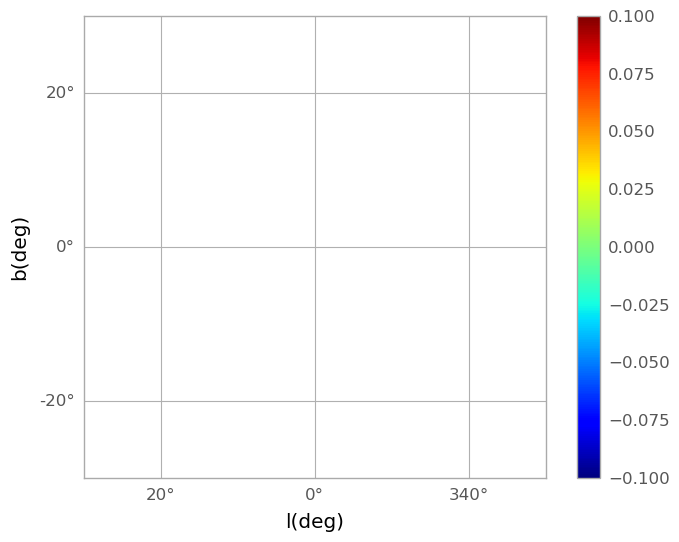

In [161]:
#disk_mask=np.load('./GC_analysis/Model/GC_disk_mask_60x60_definitions.npy')
#exposure=fits.open('./GC_analysis/GC_all_time_60x60_expcube_front_center_12yr.fits')[0].data
#src_1=fits.open('./GC_analysis/Allsky_all_time_60x60_cmap_front_12yr_AIT.fits')
#src_1=fits.open('./GC_analysis/Allsky_all_time_60x60_cmap_front_12yr_AIT.fits')
src_2=fits.open('./FermiLAT/wimp_map_CAR_test_3.fits')
w=WCS(src_2[0].header)


fig=plt.figure()
ax=fig.add_subplot(111,projection=w)
ax.coords[0].set_format_unit('deg', decimal=True, show_decimal_unit=True)
ax.coords[1].set_format_unit('deg', decimal=True, show_decimal_unit=True) #Changing coordinate tick label into decimal.
n=0
plot=ax.imshow( np.log(src_2[0].data - src_1[0].data), origin='lower', cmap='jet', interpolation='none')
#plot=ax.imshow(copied[10])
#plot=ax.imshow(full_mask[10])
#plt.grid(color='white', ls='solid')
plt.xlabel('l(deg)')
plt.ylabel('b(deg)')
plt.colorbar(plot)


Set MJD-END to 59323.999942 from DATE-END'. [astropy.wcs.wcs]


TypeError: Invalid shape (600,) for image data

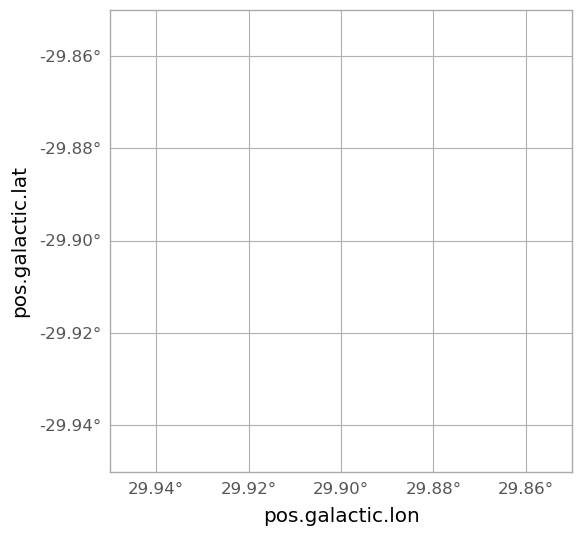

In [269]:
#disk_mask=np.load('./GC_analysis/Model/GC_disk_mask_60x60_definitions.npy')
#exposure=fits.open('./GC_analysis/GC_all_time_60x60_expcube_front_center_12yr.fits')[0].data
#src_1=fits.open('./GC_analysis/Allsky_all_time_60x60_cmap_front_12yr_AIT.fits')
#src_1=fits.open('./GC_analysis/Allsky_all_time_60x60_cmap_front_12yr_AIT.fits')
src_2=fits.open('./FermiLAT/wimp_map_CAR_test.fits')
w=WCS(src_1[0].header)


fig=plt.figure()
ax=fig.add_subplot(111,projection=w)
ax.coords[0].set_format_unit('deg', decimal=True, show_decimal_unit=True)
ax.coords[1].set_format_unit('deg', decimal=True, show_decimal_unit=True) #Changing coordinate tick label into decimal.
n=0
plot=ax.imshow( (src_1[0].data - src_2[0].data)[0], origin='lower', cmap='jet', interpolation='none')
#plot=ax.imshow(copied[10])
#plot=ax.imshow(full_mask[10])
#plt.grid(color='white', ls='solid')
plt.xlabel('l(deg)')
plt.ylabel('b(deg)')
plt.colorbar(plot)


In [270]:
np.sum(src_1[0].data - src_2[0].data)

0.0

In [5]:
#disk_mask=np.load('./GC_analysis/Model/GC_disk_mask_60x60_definitions.npy')
#exposure=fits.open('./GC_analysis/GC_all_time_60x60_expcube_front_center_12yr.fits')[0].data
#src_1=fits.open('./GC_analysis/Allsky_all_time_60x60_cmap_front_12yr_AIT.fits')
#src_1=fits.open('./GC_analysis/Allsky_all_time_60x60_cmap_front_12yr_AIT.fits')
src_1=fits.open('./FermiLAT/wimp_map_AIT_highresol.fits')
#src_1=fits.open('./GC_analysis/GC_all_time_60x60_cmap_front_12yr_CAR_highresol.fits')
w=WCS(src_1[0].header)


fig=plt.figure()
ax=fig.add_subplot(111,projection=w)
ax.coords[0].set_format_unit('deg', decimal=True, show_decimal_unit=True)
ax.coords[1].set_format_unit('deg', decimal=True, show_decimal_unit=True) #Changing coordinate tick label into decimal.
n=0
plot=ax.imshow( np.log(src_1[0].data), origin='lower', cmap='jet', interpolation='none')
#plot=ax.imshow(copied[10])
#plot=ax.imshow(full_mask[10])
#plt.grid(color='white', ls='solid')
plt.xlabel('l(deg)')
plt.ylabel('b(deg)')
plt.colorbar(plot)


FileNotFoundError: [Errno 2] No such file or directory: './FermiLAT/wimp_map_AIT_highresol.fits'

Set MJD-END to 59323.999942 from DATE-END'. [astropy.wcs.wcs]


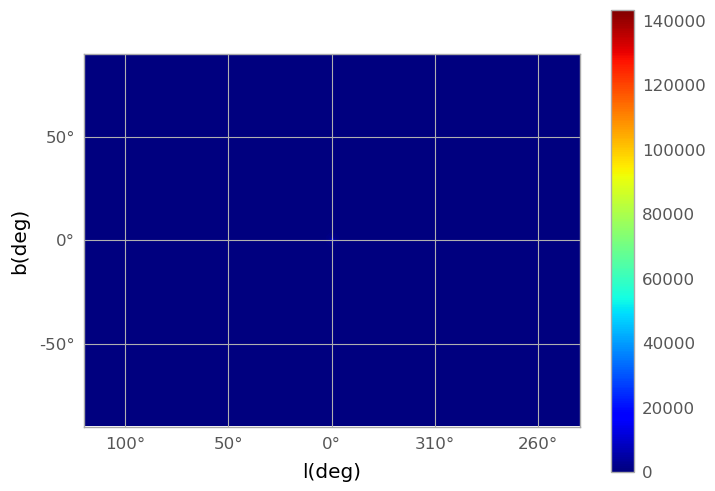

In [190]:
#disk_mask=np.load('./GC_analysis/Model/GC_disk_mask_60x60_definitions.npy')
#exposure=fits.open('./GC_analysis/GC_all_time_60x60_expcube_front_center_12yr.fits')[0].data
#src_1=fits.open('./GC_analysis/Allsky_all_time_60x60_cmap_front_12yr_AIT.fits')
#src_1=fits.open('./GC_analysis/Allsky_all_time_60x60_cmap_front_12yr_AIT.fits')
src_2=fits.open('./FermiLAT/wimp_map_CAR.fits')
w=WCS(src_2[0].header)


fig=plt.figure()
ax=fig.add_subplot(111,projection=w)
ax.coords[0].set_format_unit('deg', decimal=True, show_decimal_unit=True)
ax.coords[1].set_format_unit('deg', decimal=True, show_decimal_unit=True) #Changing coordinate tick label into decimal.
n=0
plot=ax.imshow( (src_2[0].data), origin='lower', cmap='jet', interpolation='none')
#plot=ax.imshow(copied[10])
#plot=ax.imshow(full_mask[10])
#plt.grid(color='white', ls='solid')
plt.xlabel('l(deg)')
plt.ylabel('b(deg)')
plt.colorbar(plot)


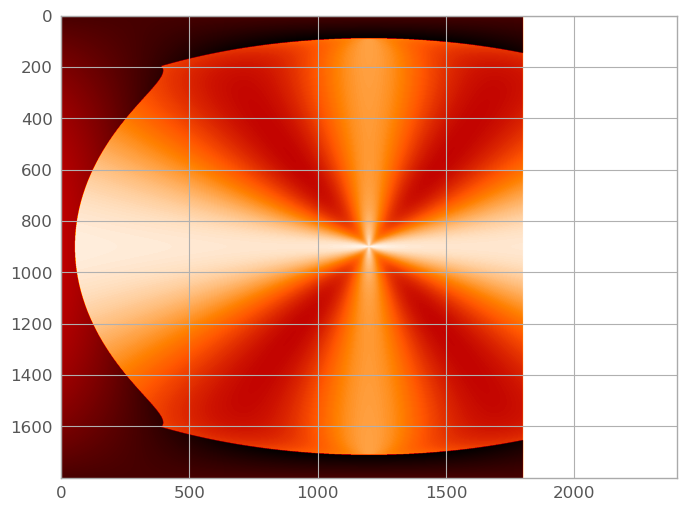

In [191]:
plt.imshow(src_1[0].data - src_2[0].data)

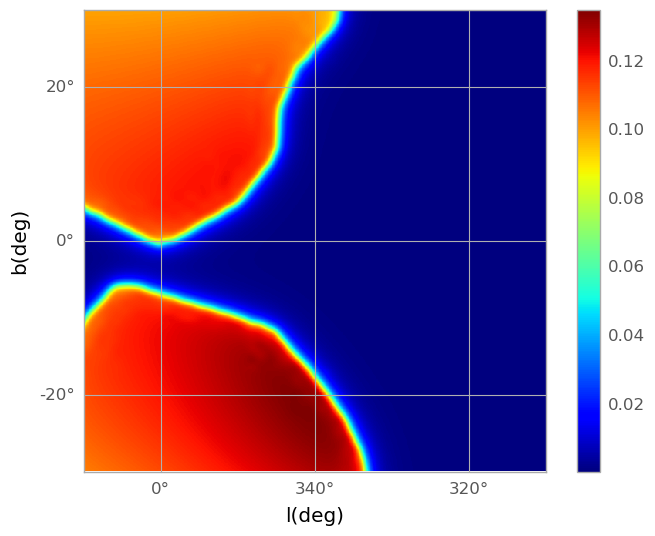

In [207]:
#disk_mask=np.load('./GC_analysis/Model/GC_disk_mask_60x60_definitions.npy')
#exposure=fits.open('./GC_analysis/GC_all_time_60x60_expcube_front_center_12yr.fits')[0].data
#src_1=fits.open('./GC_analysis/Allsky_all_time_60x60_cmap_front_12yr_AIT.fits')
#src_1=fits.open('./GC_analysis/Allsky_all_time_60x60_cmap_front_12yr_AIT.fits')
src_1=fits.open('./GC_analysis/Model/GC_all_time_60x60_fermi_bubble_model_front_12yr_evtype_corrected_l-20.fits')
w=WCS(src_1[0].header)


fig=plt.figure()
ax=fig.add_subplot(111,projection=w.dropaxis(2))
ax.coords[0].set_format_unit('deg', decimal=True, show_decimal_unit=True)
ax.coords[1].set_format_unit('deg', decimal=True, show_decimal_unit=True) #Changing coordinate tick label into decimal.
n=0
plot=ax.imshow( (src_1[0].data[0]), origin='lower', cmap='jet', interpolation='none')
#plot=ax.imshow(copied[10])
#plot=ax.imshow(full_mask[10])
#plt.grid(color='white', ls='solid')
plt.xlabel('l(deg)')
plt.ylabel('b(deg)')
plt.colorbar(plot)


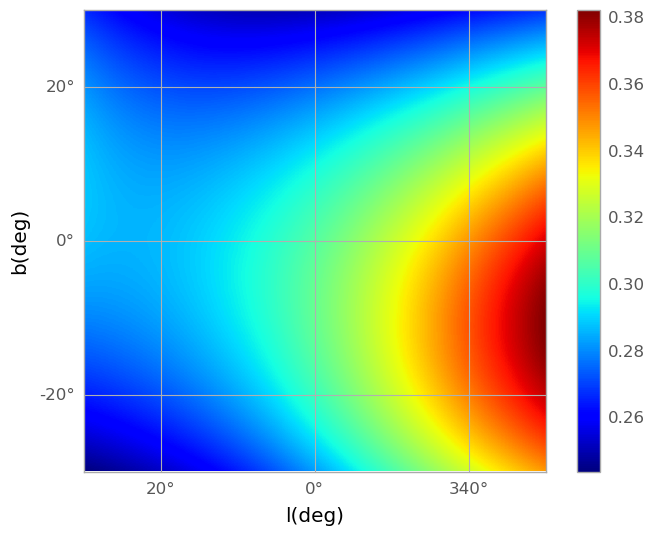

In [223]:
#disk_mask=np.load('./GC_analysis/Model/GC_disk_mask_60x60_definitions.npy')
#exposure=fits.open('./GC_analysis/GC_all_time_60x60_expcube_front_center_12yr.fits')[0].data
#src_1=fits.open('./GC_analysis/Allsky_all_time_60x60_cmap_front_12yr_AIT.fits')
#src_1=fits.open('./GC_analysis/Allsky_all_time_60x60_cmap_front_12yr_AIT.fits')
src_1=fits.open('./GC_analysis/Model/GC_all_time_60x60_isotropic_model_front_12yr_evtype_corrected.fits')
w=WCS(src_1[0].header)


fig=plt.figure()
ax=fig.add_subplot(111,projection=w.dropaxis(2))
ax.coords[0].set_format_unit('deg', decimal=True, show_decimal_unit=True)
ax.coords[1].set_format_unit('deg', decimal=True, show_decimal_unit=True) #Changing coordinate tick label into decimal.
n=0
plot=ax.imshow( (src_1[0].data[0]), origin='lower', cmap='jet', interpolation='none')
#plot=ax.imshow(copied[10])
#plot=ax.imshow(full_mask[10])
#plt.grid(color='white', ls='solid')
plt.xlabel('l(deg)')
plt.ylabel('b(deg)')
plt.colorbar(plot)


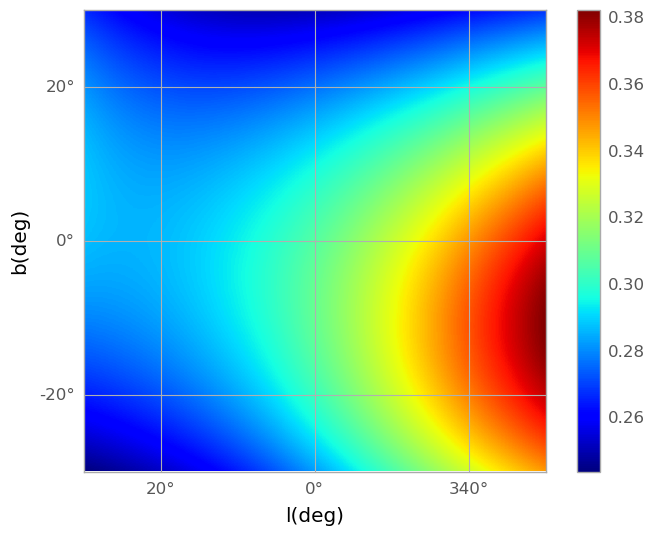

In [224]:
#disk_mask=np.load('./GC_analysis/Model/GC_disk_mask_60x60_definitions.npy')
#exposure=fits.open('./GC_analysis/GC_all_time_60x60_expcube_front_center_12yr.fits')[0].data
#src_1=fits.open('./GC_analysis/Allsky_all_time_60x60_cmap_front_12yr_AIT.fits')
#src_1=fits.open('./GC_analysis/Allsky_all_time_60x60_cmap_front_12yr_AIT.fits')
src_2=fits.open('./GC_analysis/Model/GC_all_time_60x60_isotropic_model_front_12yr_evtype_corrected-Copy1.fits')
w=WCS(src_2[0].header)


fig=plt.figure()
ax=fig.add_subplot(111,projection=w.dropaxis(2))
ax.coords[0].set_format_unit('deg', decimal=True, show_decimal_unit=True)
ax.coords[1].set_format_unit('deg', decimal=True, show_decimal_unit=True) #Changing coordinate tick label into decimal.
n=0
plot=ax.imshow( (src_2[0].data[0]), origin='lower', cmap='jet', interpolation='none')
#plot=ax.imshow(copied[10])
#plot=ax.imshow(full_mask[10])
#plt.grid(color='white', ls='solid')
plt.xlabel('l(deg)')
plt.ylabel('b(deg)')
plt.colorbar(plot)


In [225]:
np.sum(src_1[0].data - src_2[0].data)

0.0

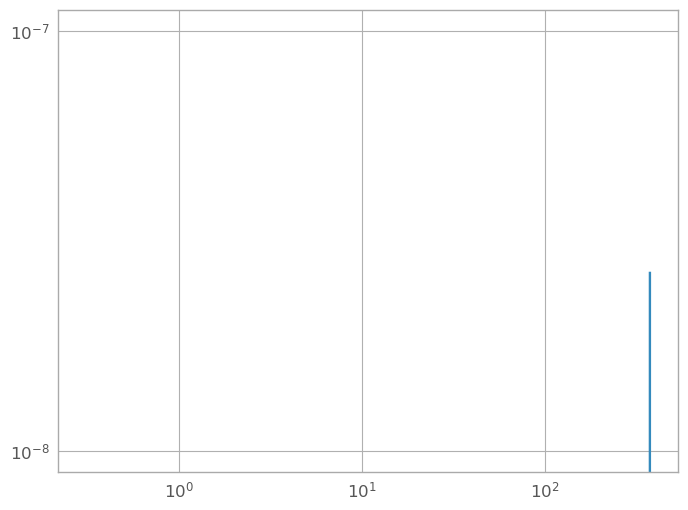

In [215]:
a=np.loadtxt('./GC_analysis/GCE_model_I_l-60.dat')
plt.loglog(a[0:, 0], a[0:, 1])

In [216]:
a

array([[ 3.13328902e-01, -1.33507666e-07,  0.00000000e+00],
       [ 4.06998780e-01, -1.43061039e-07,  0.00000000e+00],
       [ 5.28953677e-01, -1.55129647e-07,  0.00000000e+00],
       [ 6.87569631e-01, -1.50524702e-07,  0.00000000e+00],
       [ 8.94248272e-01, -1.31854317e-07,  0.00000000e+00],
       [ 1.16034479e+00, -1.05572695e-07,  0.00000000e+00],
       [ 1.50678468e+00, -1.01173021e-07,  0.00000000e+00],
       [ 1.96285509e+00, -1.02971719e-07,  0.00000000e+00],
       [ 2.55311571e+00, -8.42876056e-08,  0.00000000e+00],
       [ 3.31659468e+00, -8.53472073e-08,  0.00000000e+00],
       [ 4.30810856e+00, -8.49281909e-08,  0.00000000e+00],
       [ 7.28203256e+00, -4.96123018e-08,  0.00000000e+00],
       [ 1.60176404e+01, -3.72414179e-08,  0.00000000e+00],
       [ 3.52324044e+01, -6.04266363e-08,  0.00000000e+00],
       [ 7.74964412e+01, -7.90142474e-08,  0.00000000e+00],
       [ 1.70459967e+02, -8.30233986e-08,  0.00000000e+00],
       [ 3.74941680e+02,  2.65126821e-08